In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_results.ipynb started: Tue, 19 May 2026 16:27:54
INFO: SETUP COMPLETE (1609.38 ms)
---------------------------------------


In [2]:
# fine = True
# DPI = 400
# filename = './/collected_data//2026_05_13//20260513-060516.vspc'
# data = read_json_formatted_file(filename)
# meas_name = filename.split('//')[3].split('.')[0]
# meas_folder = filename.split('//')[2]

# energyPerBin = data['Calibration']['BinSize_keV/Bin'] # keV/bin
# bin_data = data['RawData'][:-1] #remove that overflow bin at position 8191
# total_counts = np.sum(bin_data)
# total_counts_incl = np.sum(data['RawData'])
# # print(bin_data)

# bins = np.arange(0,len(bin_data),1)

# scatter_color = color_schemes['c_dark']

# fig, ax = plt.subplots(figsize=(40,4), dpi=DPI)
# # ax.set_facecolor(color_schemes['c_back'])
# # ax.plot(bins, bin_data, lw=0.75, color=scatter_color[0], zorder=2)
# ax.step(bins, bin_data, lw=0.75, color=scatter_color[3], zorder=2)

# if (len(bin_data) == 8191):
#     ax.set_xlim(0,8193)
#     ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
#     if fine == True:
#        ax.set_xticks(np.arange(0,8193,64),np.arange(0,8193,64)) 
# elif (len(bin_data) == 4095):
#     ax.set_xlim(0,4095)
#     ax.set_xticks(np.arange(0,4097,512),np.arange(0,4097,512))
# elif (len(bin_data) == 2047):
#     ax.set_xlim(0,2047)
#     ax.set_xticks(np.arange(0,2049,512),np.arange(0,2049,512))


# secax = ax.secondary_xaxis('top')
# secax.set_xlim(0,8193)
# secax.set_xticks(np.arange(0,8193,64),list(np.arange(0,(8193*2.3866),(64*2.3866)).round(1)), rotation=30, ha='left')
# secax.set_xlabel('Energy / eV', fontsize=6)
    
# plt.xlabel('MCA channel')
# plt.ylabel('Counts')

# plt.yscale('log')

# plt.grid(which="both")
# plt.tight_layout()

# #----------------- Information Box -----------------#
# #det_pic_file = detector_pic(measurement['det_id'])
# # img = plt.imread(det_pic_file)
# annotation = TextArea(f"X-ray measurement \n {meas_name} \n RAW DATA \n Total Counts: {total_counts}", textprops=dict(color="black", fontsize=5, multialignment='center'))
# # imagebox = OffsetImage(img, zoom=0.05)
# stacked = VPacker(children=[annotation],
#                 align="center",
#                 pad=0,
#                 sep=5)

# ab = AnnotationBbox(offsetbox=stacked, xy=(0.9,0.85), xycoords='axes fraction', frameon=True)

# ax.add_artist(ab)
# #----------------- Information Box -----------------#


# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.png', dpi=DPI)
# plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_wide.pdf', dpi=DPI)

In [3]:
# f_n = all_files_from_measSet('2026_02_26')
# f_n = all_files_from_measSet('2026_02_27')
# f_n = all_files_from_measSet('2026_03_25')
# f_n = all_files_from_measSet('collected_data//2026_05_13')

## To-Do:

#### Energy Calibration with Amersham Source Data

#### Upload to Confluence: Docu for Detector

In [93]:
def peak_fitter(file:str, init_values:list, gauss_ident:str, select_window:list):
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bin_data_selected = bin_data[select_window[0]:select_window[1]+1]
    bin_data_zerofixed = np.where(bin_data_selected == 0, 1, bin_data_selected)
    data_err = np.sqrt(bin_data_zerofixed)
    
    bins = np.arange(0,len(bin_data),1)
    bins_selected = bins[select_window[0]:select_window[1]+1]
    bins_err = np.array([2]*len(bins_selected))
    
    if (gauss_ident == 'single'):
        beta = evaluator_scipy(func=gauss_func, beta0_list=init_values,
                           x=bins_selected, y=bin_data_selected, xerr=bins_err, yerr=data_err)
    elif (gauss_ident == 'double'):
        beta = evaluator_scipy(func=double_gauss_func, beta0_list=init_values,
                           x=bins_selected, y=bin_data_selected, xerr=bins_err, yerr=data_err)
    elif (gauss_ident == 'single_lin'):
        beta = evaluator_scipy(func=gauss_linear_func, beta0_list=init_values,
                           x=bins, y=bin_data, xerr=bins_err, yerr=data_err)
    
    return beta

### To-Do

- Voigt Profile
- Presentation Flag (larger legend, ticks and labels)
- measurement name Flag
- xraydb implementation for manual search
- Double Gauss Split Flag
- Force Gauss from Init Values Flag (see a certain Rb-Measurement)
- For Spectra later, add overlapping lines where fit didn't find them

In [65]:
def all_peaks_one_measurement(file:str, peaks:list, xlim:list, ylim:list, info:list, col_flag:bool, identifier:str, gauss_ident:list):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_data_zerofixed = np.where(bin_data == 0, 1, bin_data)
    data_err = np.sqrt(bin_data_zerofixed)
    
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]}')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
        beta= peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p])
        beta_export = [beta['param'],beta['errors']]
        
        
        if (gauss_ident[p] == 'single'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'single_lin'):
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_linear_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
              
        
            
        csv_file_name = f'.//peak_idents//{meas_folder}//{meas_name}_peaks_{identifier}.csv'
        
        with open(csv_file_name, mode='a', newline='', encoding='utf-8') as csv_file:
            writer = csv.writer(csv_file)
            writer.writerows(beta_export)
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [87]:
def find_selection_window(peaks,bin_grad,gauss_type):
    if (gauss_type == 's'):
        start_idx = peaks[1]
        #LEFT
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                print('L:',closest_idx_left)
                break
        #RIGHT
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    elif (gauss_type == 'd'):
        #LEFT
        start_idx = np.min([peaks[1],peaks[4]])
        idx = start_idx - 10
        for i in range(idx,0,-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i+1])):
                continue
            else:
                closest_idx_left = i
                print('L:',closest_idx_left)
                break
        #RIGHT
        start_idx = np.max([peaks[1],peaks[4]])
        idx = start_idx + 10
        for i in range(idx,len(bin_grad)-1):
            if (np.sign(bin_grad[i]) == np.sign(bin_grad[i-1])):
                continue
            else:
                closest_idx_right = i
                print('R:',closest_idx_right)
                break
        
        select_window=[closest_idx_left,closest_idx_right+1]
        
    return select_window

def selection_fitter_plotter(file:str, peaks:list, xlim:list, ylim:list, info:list, col_flag:bool, identifier:str, gauss_ident:list):
    
    DPI = 300
    scatter_color = color_schemes['c_dark']
    
    if (col_flag == True):
        gauss_color = color_schemes['c_light']
        gcp = [1,5]
    elif (col_flag == False):
        gauss_color = color_schemes['c_complementary']
        gcp = [0,3,4,5,6,7]
    
    data = read_json_formatted_file(file)
    
    bin_data = np.array(data['RawData'][:-1])
    bins = np.arange(0,len(bin_data),1)
    bin_grad = np.gradient(bin_data)
    meas_name = file.split('//')[3].split('.')[0]
    meas_folder = file.split('//')[2]
    
    _,ax = plt.subplots(figsize=(5,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]} / {meas_name}')
    plt.step(bins, bin_data, lw=0.75, color='black', zorder=3, label=f'{info[0]}')
    # plt.fill_between(bins, bin_data - data_err, bin_data + data_err, step='mid', color='black', alpha=0.3, zorder=2, label='Poissonian error')
    
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    for p in range(len(peaks)):
               
        if (gauss_ident[p] == 'single'): 
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='s')
            plt.fill_betweenx(y=[0,peaks[p][0]],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1)
            
            beta = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window)
            
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            
            plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'double'):
            select_window = find_selection_window(peaks[p], bin_grad, gauss_type='d')
            plt.fill_betweenx(y=[0,peaks[p][0]],x1=select_window[0],x2=select_window[1],color=gauss_color[gcp[p]], zorder=2, alpha=0.15, lw=0.1)
            
            beta = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p], select_window=select_window)
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][4]*1.05)
            plt.plot(bins[gauss_left:gauss_right],double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][:3], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.plot(bins[gauss_left:gauss_right],gauss_func(beta['param'][3:], bins[gauss_left:gauss_right]),lw=.6, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
            # plt.fill_between(x=bins[gauss_left:gauss_right],y1=double_gauss_func(beta['param'], bins[gauss_left:gauss_right]),alpha=0.4, color=gauss_color[gcp[p]], zorder=2, label=fr'{info[p+1]} - line fit')
        elif (gauss_ident[p] == 'single_lin'):
            beta = peak_fitter(file=file, init_values=peaks[p], gauss_ident=gauss_ident[p])
            gauss_left = int(beta['param'][1]*0.95)
            gauss_right = int(beta['param'][1]*1.05)
            plt.plot(bins[gauss_left:gauss_right],gauss_linear_func(beta['param'], bins[gauss_left:gauss_right]),lw=1, color=gauss_color[gcp[p]], zorder=3, label=fr'{info[p+1]} - line fit')
              
        
    plt.grid(which='both')
    plt.xlim(xlim[0],xlim[1])
    if (ylim != []):
        plt.ylim(ylim[0],ylim[1])
    plt.legend(loc='best', fontsize=5)
    plt.tight_layout()
    
    # plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.png', dpi=DPI)
    # plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}_peaks_{identifier}.pdf', dpi=DPI)
    
    plt.show()

In [88]:
def grab_xrays(elem:str):
    l_fmt = '%7s  %9.1f   %8.5f  %11s'
    print('# X-ray Lines:')
    print('#  Line     Energy  Intensity       Levels')
    for key, val in xraydb.xray_lines(elem).items():
        levels = '%s-%s' % (val.initial_level, val.final_level)
        print(l_fmt % (key, val.energy, val.intensity, levels))
    return 69

## 3400 (~7.6 eV/MCA) @ 8192 10h

<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\g'
C:\Users\schum\AppData\Local\Temp\ipykernel_2368\3562373986.py:12: SyntaxWarning: invalid escape sequence '\g'
  info1 = ['Americium', '$\gamma_{2,0}$']


L: 1027
R: 1103
PARAMS: [5738.42576624 1056.866133      8.93829342  643.86290003 1089.32882874
   10.11128121]
UNCERT: [53.0279306   0.26454173  0.15553363 10.17711865  0.43342902  0.60620959]
L: 1108
R: 1195
PARAMS: [4620.87512161 1134.39345095    9.07737305  965.20177523 1171.99086943
    9.96085612]
UNCERT: [39.57722042  0.19919274  0.12512631 11.49208989  0.23545084  0.20094885]


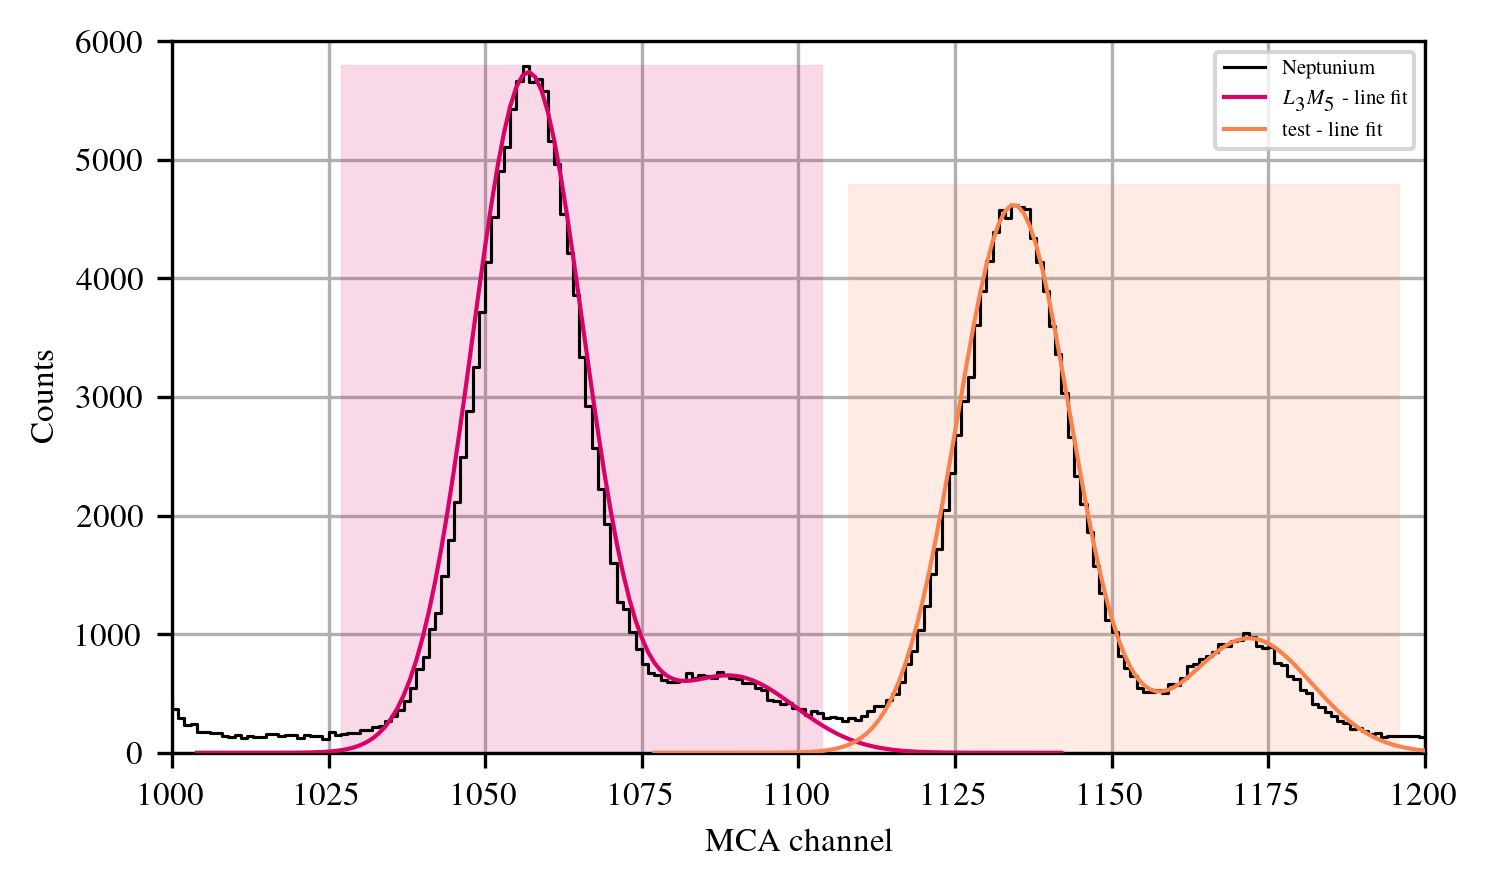

In [99]:
file_to_analyze = './/collected_data//2026_05_13//20260513-160638.vspc'

init_val1 = [[1800,7820,22]]
init_val2 = [[5800,1060,9,700,1080,11],[4800,1134,9,1000,1168,10]]
init_val3 = [[55000,1825,50]]
xlim1 = [7500,8000]
xlim2 = [1000,1200]
xlim3 = [1750,1900]
ylim1 = [0,2000]
ylim2 = [0,6000]
ylim3 = []
info1 = ['Americium', '$\gamma_{2,0}$']
info2 = ['Neptunium', '$L_3M_5$', 'test','test']
info3 = ['Neptunium', '$L_3M_5$']
gauss1 = ['single']
gauss2 = ['double','double']
gauss3 = ['single']

# selection_fitter_plotter(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
selection_fitter_plotter(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=False, identifier='1', gauss_ident=gauss2)



# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val1, xlim=xlim1, ylim=ylim1, info=info1, col_flag=True, identifier='0', gauss_ident=gauss1)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val2, xlim=xlim2, ylim=ylim2, info=info2, col_flag=True, identifier='1', gauss_ident=gauss2)
# all_peaks_one_measurement(file = file_to_analyze, peaks = init_val3, xlim=xlim3, ylim=ylim3, info=info3, col_flag=True, identifier='3', gauss_ident=gauss3)